In [186]:
import numpy as np
import pandas as pd
import random

In [187]:
df = pd.read_csv('cities.csv')

df = df.rename(columns ={'0.046':'x', '4.006': 'y'})
df.head()


,x,y
0,-0.454,-0.706
1,0.181,5.769
2,0.739,4.741
3,-0.110,5.179
4,-0.235,0.271


In [188]:
centers = df[['x','y']].sample(3).to_numpy().tolist()
centers

[[-0.265, 5.257], [-0.454, -0.706], [4.447, 4.402]]

In [189]:
def assign_clusters(df, centers):
    clusters = {0:[], 1:[], 2:[]}
    
    for idx, row in df.iterrows():
        x,y = row['x'], row['y']

        distance = []
        for cx, cy in centers:
            dist = (cx-x)**2 + (cy-y)**2
            distance.append(dist)

        nearest = distance.index(min(distance))
        clusters[nearest].append((x, y))
    return clusters

In [190]:
clusters = assign_clusters(df,centers)

In [191]:
def update_centers_gd(clusters, lr=0.01, iterations =50):
    new_centers = []

    for k in clusters:
        points = clusters[k]

        if len(points) ==0:
            new_centers.append((0,0))
            continue

        cx = sum(p[0] for p in points)/len(points)
        cy = sum(p[1] for p in points)/len(points)

        for _ in range(iterations):
            grad_x = -2 * sum((x-cx) for x, y in points)
            grad_y = -2 * sum((y-cy) for x,y in points)

            cx = cx -lr*grad_x
            cy = cy -lr*grad_y
        
        new_centers.append((cx,cy))
    return new_centers

In [192]:
new_centers_gd = update_centers_gd(clusters)

In [193]:
def update_centers_newton(clusters):
    new_centers = []

    for k in clusters:
        points = clusters[k]

        if len(points) == 0:
            new_centers.append((0, 0))
            continue

        cx = sum(p[0] for p in points) / len(points)
        cy = sum(p[1] for p in points) / len(points)

        new_centers.append((cx, cy))

    return new_centers

In [194]:
new_centers_newton = update_centers_newton(clusters)
new_centers_newton

[(np.float64(-0.05673333333333332), np.float64(5.078733333333333)),
 (np.float64(-0.09476470588235293), np.float64(-0.06588235294117643)),
 (np.float64(4.942764705882353), np.float64(4.948882352941176))]

In [195]:
def compute_cost(clusters, centers):
    total_cost = 0

    for k in clusters:
        cx, cy = centers[k]

        for x, y in clusters[k]:
            dist = (x - cx)**2 + (y - cy)**2
            total_cost += dist

    return total_cost

In [196]:
# Gradient Descent
clusters_gd = assign_clusters(df, new_centers_gd)
cost_gd = compute_cost(clusters_gd, new_centers_gd)

# Newton Method
clusters_nt = assign_clusters(df, new_centers_newton)
cost_nt = compute_cost(clusters_nt, new_centers_newton)

print("Cost_GD:", cost_gd)
print("Cost_nt", cost_nt)

Cost_GD: 19.226477513725484
Cost_nt 19.22647751372548


In [197]:
best_centers = None
best_loss = float('inf')

for _ in range(10):  # run 10 times
    centers = df[['x','y']].sample(3).to_numpy().tolist()

    for i in range(10):  # k-means iterations
        clusters = assign_clusters(df, centers)
        centers = update_centers_newton(clusters)

    # compute loss (SSE)
    loss = 0
    for k in clusters:
        for x, y in clusters[k]:
            cx, cy = centers[k]
            loss += (x - cx)**2 + (y - cy)**2

    if loss < best_loss:
        best_loss = loss
        best_centers = centers

[]

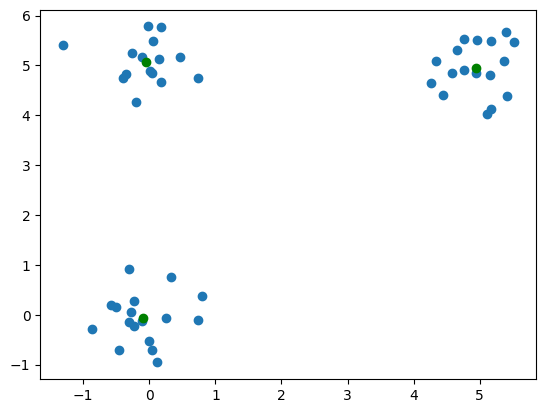

In [198]:
from matplotlib import pyplot as plt

plt.scatter(df['x'], df['y'])

center_x = [center[0] for center in best_centers]
center_y = [center[1] for center in best_centers]

plt.scatter(center_x, center_y, color='green')
plt.plot()

